# SDC-2023 Multipath — Exploratory Data Analysis & Feature Engineering

Explores the 2023 GNSS measurement dataset and engineers the feature matrix for the classifier. The label is each device's own `MultipathIndicator`.

**Input:** `data/02_interim/sdc2023_epochs.csv`

**Output:** `data/03_processed/sdc2023_training_features.csv`

## 1. Library Import & Data Loading

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

BASE_DIR   = os.path.abspath(os.path.join(os.getcwd(), '../..'))
INPUT_CSV  = os.path.join(BASE_DIR, 'data/02_interim/sdc2023_epochs.csv')
OUTPUT_DIR = os.path.join(BASE_DIR, 'data/03_processed')
OUTPUT_CSV = os.path.join(OUTPUT_DIR, 'sdc2023_training_features.csv')
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(INPUT_CSV)
pd.set_option('display.max_columns', None)
print(f'Loaded {len(df):,} rows from {INPUT_CSV}')
df.head()

Loaded 761,597 rows from C:\Users\Dell\Documents\Warwick\Diss\Code\Dissertation_Trial\GNSS_Multipath_Project\data/02_interim/sdc2023_epochs.csv


,State,Svid,ReceivedSvTimeUncertaintyNanos,Cn0DbHz,BasebandCn0DbHz,SnrInDb,AgcDb,PseudorangeRateMetersPerSecond,PseudorangeRateUncertaintyMetersPerSecond,AccumulatedDeltaRangeState,AccumulatedDeltaRangeMeters,AccumulatedDeltaRangeUncertaintyMeters,CarrierFrequencyHz,ConstellationType,MultipathIndicator,SvElevationDegrees,SvAzimuthDegrees,RawPseudorangeMeters,RawPseudorangeUncertaintyMeters,session,device,GpsTimeNanos,prResidual
0,16431,6,14,41.710907,NaN,NaN,NaN,-164.962361,0.150000,25,-11668.937690,0.001196,1.575420e+09,1,0,54.479871,128.729618,2.090664e+07,4.197094,2023-03-08-21-34-us-ca-mtv-u,pixel6pro,336907000248129,-17.517512
1,16431,11,50,26.527052,NaN,NaN,NaN,-534.366362,0.940767,29,-37277.453867,0.006478,1.575420e+09,1,0,28.062975,175.168830,2.299924e+07,14.989623,2023-03-08-21-34-us-ca-mtv-u,pixel6pro,336907000248129,20.691331
2,16431,12,27,34.177910,NaN,NaN,NaN,-402.783540,0.596536,25,-27997.748699,0.002685,1.575420e+09,1,0,23.090938,296.403147,2.329942e+07,8.094396,2023-03-08-21-34-us-ca-mtv-u,pixel6pro,336907000248129,20.895644
3,16431,17,14,42.474239,NaN,NaN,NaN,616.955107,0.150000,25,43134.044729,0.001096,1.575420e+09,1,0,36.711941,46.197646,2.242312e+07,4.197094,2023-03-08-21-34-us-ca-mtv-u,pixel6pro,336907000248129,-19.880819
4,16431,19,16,40.274414,NaN,NaN,NaN,350.406984,0.150000,25,24380.856235,0.001411,1.575420e+09,1,0,67.378019,30.702359,2.035373e+07,4.796679,2023-03-08-21-34-us-ca-mtv-u,pixel6pro,336907000248129,-5.631828


## 2. Dataset Overview

In [ ]:
print('--- Info ---')
df.info()
print('\n--- Statistical Summary ---')
df.describe()

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761597 entries, 0 to 761596
Data columns (total 23 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   State                                      761597 non-null  int64  
 1   Svid                                       761597 non-null  int64  
 2   ReceivedSvTimeUncertaintyNanos             761597 non-null  int64  
 3   Cn0DbHz                                    761597 non-null  float64
 4   BasebandCn0DbHz                            0 non-null       float64
 5   SnrInDb                                    0 non-null       float64
 6   AgcDb                                      0 non-null       float64
 7   PseudorangeRateMetersPerSecond             761597 non-null  float64
 8   PseudorangeRateUncertaintyMetersPerSecond  761597 non-null  float64
 9   AccumulatedDeltaRangeState                 761597 non-null  int64  


,State,Svid,ReceivedSvTimeUncertaintyNanos,Cn0DbHz,BasebandCn0DbHz,SnrInDb,AgcDb,PseudorangeRateMetersPerSecond,PseudorangeRateUncertaintyMetersPerSecond,AccumulatedDeltaRangeState,AccumulatedDeltaRangeMeters,AccumulatedDeltaRangeUncertaintyMeters,CarrierFrequencyHz,ConstellationType,MultipathIndicator,SvElevationDegrees,SvAzimuthDegrees,RawPseudorangeMeters,RawPseudorangeUncertaintyMeters,GpsTimeNanos,prResidual
count,761597.000000,761597.000000,761597.000000,761597.000000,0.0,0.0,0.0,761597.000000,761597.000000,761597.000000,7.615970e+05,7.615970e+05,7.287140e+05,761597.000000,761597.000000,721832.000000,721832.000000,7.218320e+05,721832.000000,7.615970e+05,721832.000000
mean,59177.698750,22.839451,26.398224,31.656356,NaN,NaN,NaN,-21.270079,15.424229,21.699917,-2.615730e+04,1.116650e+38,1.414613e+09,3.515842,0.070172,38.283167,186.367063,2.430515e+07,7.571669,3.407686e+14,-34.379787
std,32504.891199,29.585828,22.716173,6.679762,NaN,NaN,NaN,394.114510,64.757628,4.255607,3.744911e+05,1.597767e+38,1.956997e+08,2.455526,0.255437,21.529580,101.358314,3.532770e+06,6.172904,7.939494e+13,3515.576446
min,16385.000000,2.000000,6.000000,12.072184,NaN,NaN,NaN,-873.894430,0.034062,16.000000,-1.797767e+06,5.154819e-04,1.176450e+09,1.000000,0.000000,2.496528,0.006927,2.007487e+07,1.798755,2.445190e+14,-296024.948632
25%,16431.000000,10.000000,8.000000,26.970236,NaN,NaN,NaN,-361.650309,0.150000,16.000000,-2.380929e+05,2.304211e-03,1.176450e+09,1.000000,0.000000,18.228909,85.394036,2.230557e+07,2.398340,2.574610e+14,-16.385391
50%,81921.000000,20.000000,20.000000,31.815979,NaN,NaN,NaN,-41.426693,0.697813,25.000000,-2.521090e+04,5.136418e-03,1.575420e+09,4.000000,0.000000,36.650374,194.289099,2.396688e+07,5.995849,3.337350e+14,0.000000
75%,84003.000000,27.000000,35.000000,36.721340,NaN,NaN,NaN,335.913829,0.977830,25.000000,1.875061e+05,3.402823e+38,1.575420e+09,6.000000,0.000000,56.744529,285.574505,2.523169e+07,10.192944,4.161640e+14,14.575824
max,85026.000000,195.000000,497.000000,49.290623,NaN,NaN,NaN,903.318633,299.798524,29.000000,1.484730e+06,3.402823e+38,1.575420e+09,6.000000,1.000000,88.568611,359.997823,4.394901e+07,148.996852,5.059000e+14,40262.703553


## 3. Target Variable Distribution

Overall class balance and the per-session breakdown.

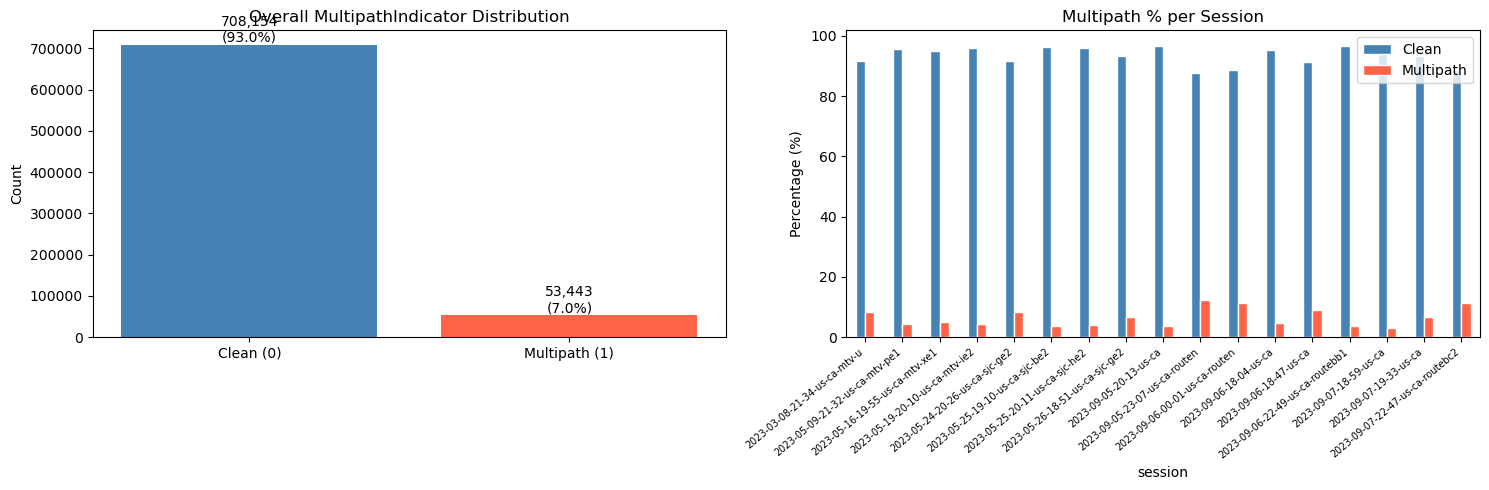

Class imbalance: 7.0% multipath


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

counts = df['MultipathIndicator'].value_counts().sort_index()
axes[0].bar(['Clean (0)', 'Multipath (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Overall MultipathIndicator Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f'{v:,}\n({100*v/len(df):.1f}%)', ha='center', va='bottom')

sess_pct = (df.groupby(['session', 'MultipathIndicator']).size()
            .unstack(fill_value=0).apply(lambda r: 100 * r / r.sum(), axis=1))
sess_pct.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Multipath % per Session')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=40, ha='right', fontsize=7)
axes[1].legend(['Clean', 'Multipath'])
plt.tight_layout()
plt.show()
print(f'Class imbalance: {100*counts.get(1,0)/len(df):.1f}% multipath')

## 4. Feature Distributions by Class

Boxplots comparing the key measurement + geometry features between clean and multipath epochs. The physical expectation: multipath measurements have **lower C/N0, lower elevation, and larger pseudorange residuals**.

C:\Users\Dell\AppData\Local\Temp\ipykernel_28560\1938765036.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
C:\Users\Dell\AppData\Local\Temp\ipykernel_28560\1938765036.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
C:\Users\Dell\AppData\Local\Temp\ipykernel_28560\1938765036.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
C:\Users\Dell\AppData\Local\Temp\ipykernel_28560\1938765036.py:19: MatplotlibDe

C:\Users\Dell\AppData\Local\Temp\ipykernel_28560\1938765036.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
C:\Users\Dell\AppData\Local\Temp\ipykernel_28560\1938765036.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
C:\Users\Dell\AppData\Local\Temp\ipykernel_28560\1938765036.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,


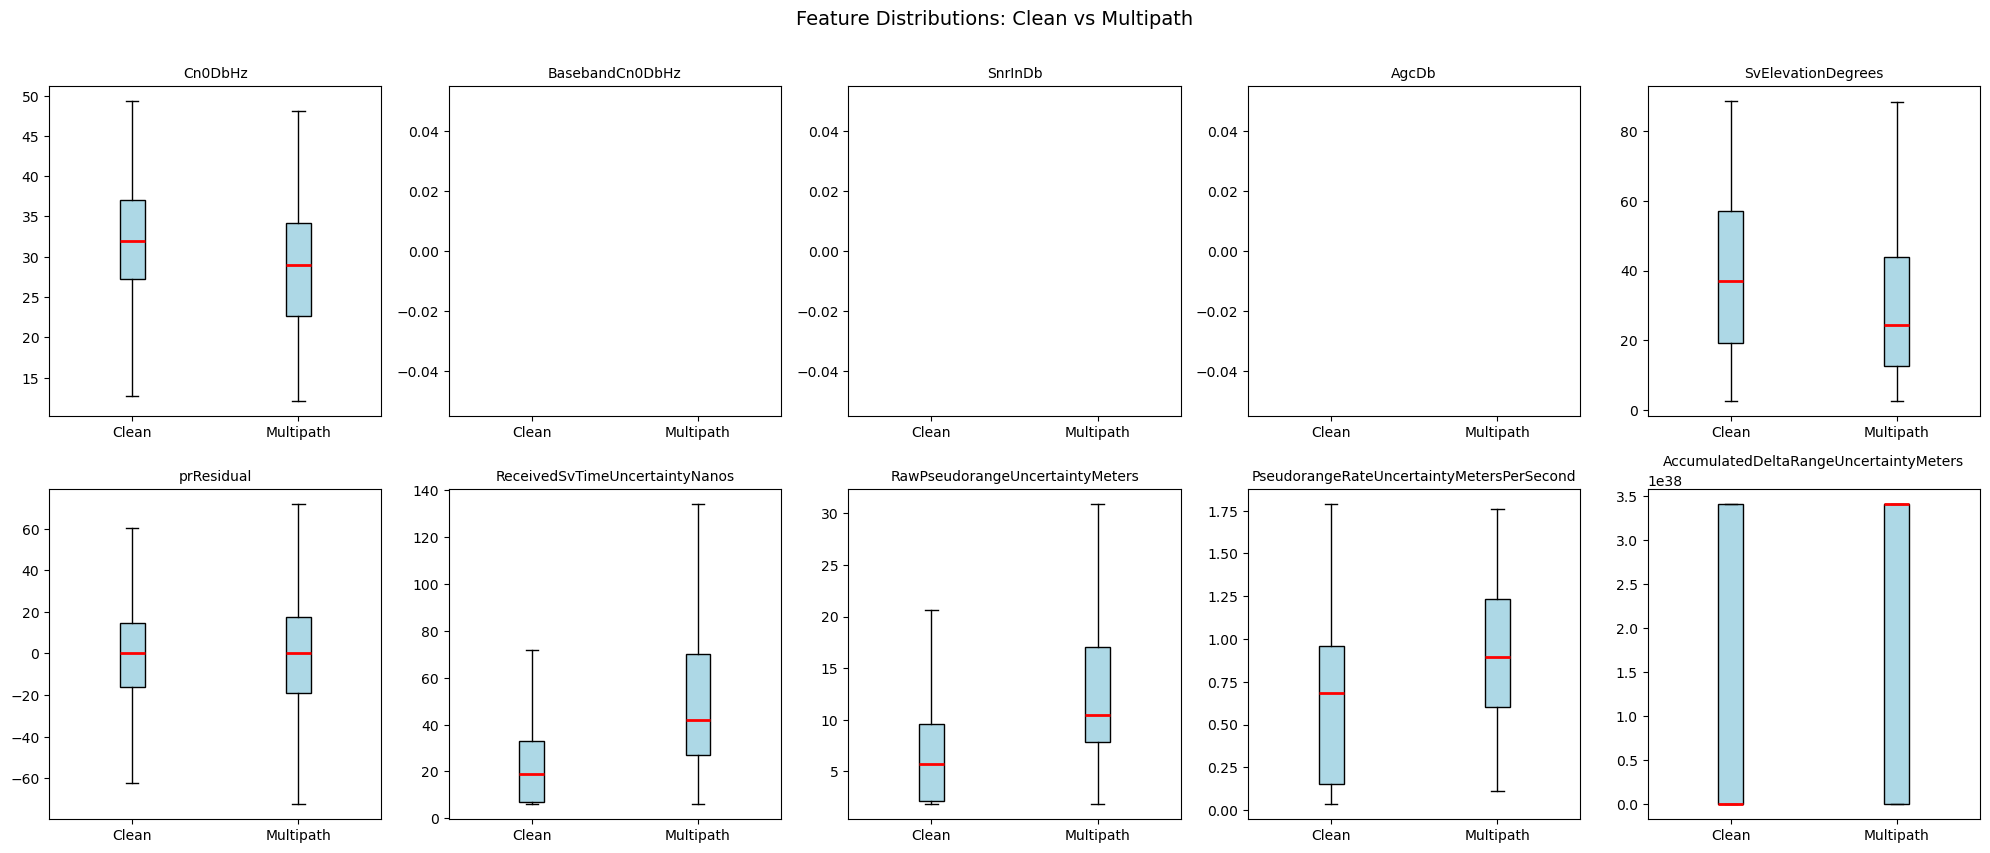

In [ ]:
PLOT_FEATURES = [
    'Cn0DbHz', 'BasebandCn0DbHz', 'SnrInDb', 'AgcDb',
    'SvElevationDegrees', 'prResidual',
    'ReceivedSvTimeUncertaintyNanos', 'RawPseudorangeUncertaintyMeters',
    'PseudorangeRateUncertaintyMetersPerSecond',
    'AccumulatedDeltaRangeUncertaintyMeters',
]
available_plot = [f for f in PLOT_FEATURES if f in df.columns]

ncols = 5
nrows = int(np.ceil(len(available_plot) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4.2 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, feat in enumerate(available_plot):
    ax = axes[i]
    data_plot = df[[feat, 'MultipathIndicator']].dropna()
    groups = [data_plot.loc[data_plot['MultipathIndicator'] == v, feat] for v in [0, 1]]
    ax.boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2), showfliers=False)
    ax.set_title(feat, fontsize=10)

for j in range(len(available_plot), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions: Clean vs Multipath', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Elevation & C/N0 — The Multipath Signature

Multipath is strongest for **low-elevation** satellites (signals grazing buildings/terrain) and shows up as **depressed C/N0**. This 2-D view makes the separation explicit.

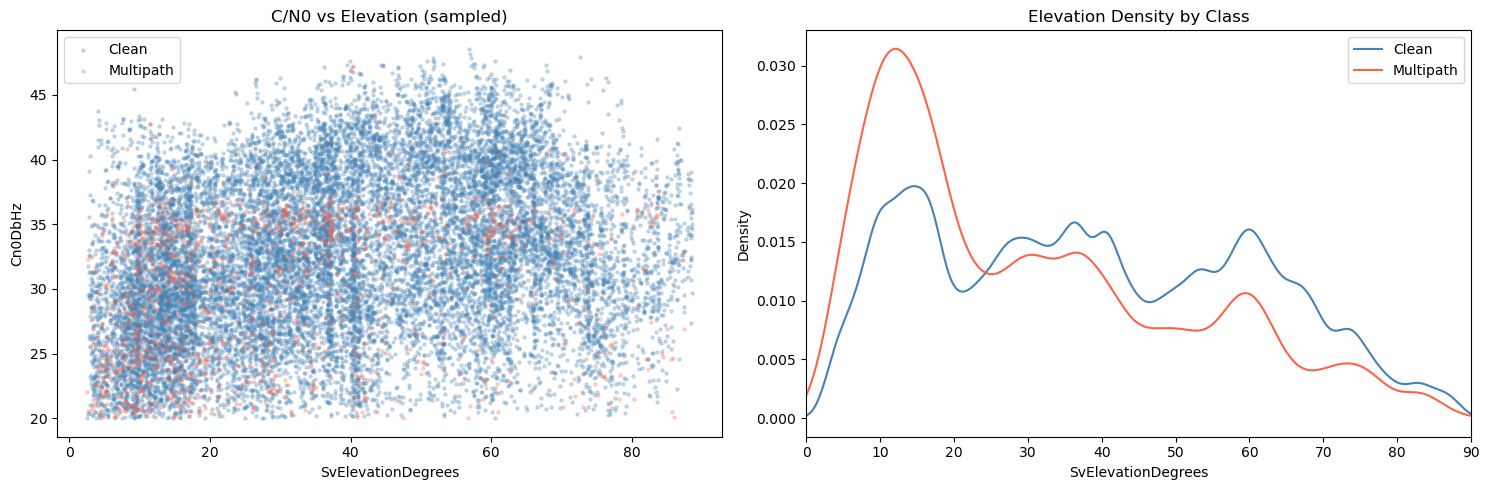

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sample = df.sample(min(20000, len(df)), random_state=42)
for val, label, color in [(0, 'Clean', 'steelblue'), (1, 'Multipath', 'tomato')]:
    sub = sample[sample['MultipathIndicator'] == val]
    axes[0].scatter(sub['SvElevationDegrees'], sub['Cn0DbHz'], s=5, alpha=0.25,
                    color=color, label=label)
axes[0].set_xlabel('SvElevationDegrees')
axes[0].set_ylabel('Cn0DbHz')
axes[0].set_title('C/N0 vs Elevation (sampled)')
axes[0].legend()

for val, label, color in [(0, 'Clean', 'steelblue'), (1, 'Multipath', 'tomato')]:
    subset = df.loc[df['MultipathIndicator'] == val, 'SvElevationDegrees'].dropna()
    subset.plot.kde(ax=axes[1], label=label, color=color)
axes[1].set_title('Elevation Density by Class')
axes[1].set_xlabel('SvElevationDegrees')
axes[1].set_xlim(0, 90)
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Constellation Breakdown

ConstellationType codes: 1=GPS, 3=GLONASS, 5=BeiDou, 6=Galileo. Checks whether some constellations are flagged for multipath more often.

MultipathIndicator   Clean  Multipath  Multipath_%
ConstellationName                                 
Galileo             324294      37062         10.3
QZSS                 17770       1692          8.7
BeiDou               11841        882          6.9
GPS                 354249      13807          3.8


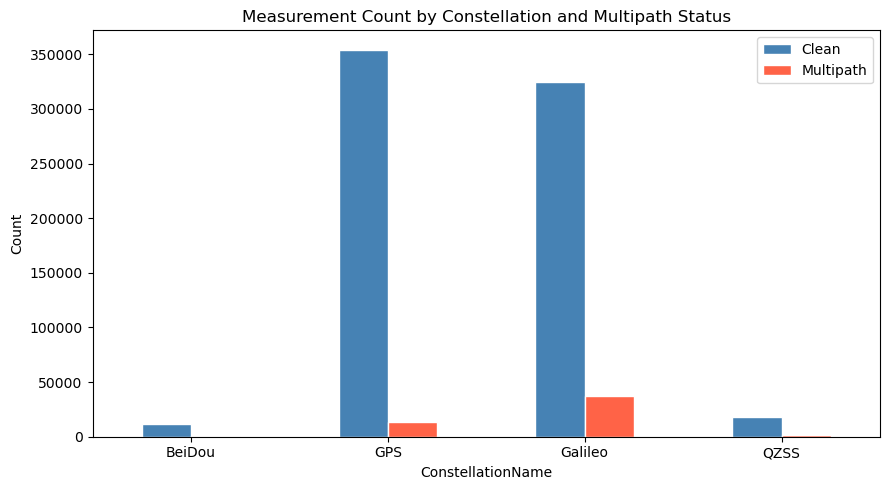

In [ ]:
CONST_NAMES = {1: 'GPS', 2: 'SBAS', 3: 'GLONASS', 4: 'QZSS', 5: 'BeiDou', 6: 'Galileo'}
df['ConstellationName'] = df['ConstellationType'].map(CONST_NAMES).fillna('Unknown')

const_mp = (df.groupby(['ConstellationName', 'MultipathIndicator']).size()
            .unstack(fill_value=0).rename(columns={0: 'Clean', 1: 'Multipath'}))
if 'Multipath' in const_mp.columns and 'Clean' in const_mp.columns:
    const_mp['Multipath_%'] = (100 * const_mp['Multipath'] / const_mp.sum(axis=1)).round(1)
print(const_mp.sort_values('Multipath_%', ascending=False))

const_mp[['Clean', 'Multipath']].plot(kind='bar', figsize=(9, 5),
        color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Measurement Count by Constellation and Multipath Status')
plt.ylabel('Count'); plt.xticks(rotation=0)
plt.legend(['Clean', 'Multipath'])
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

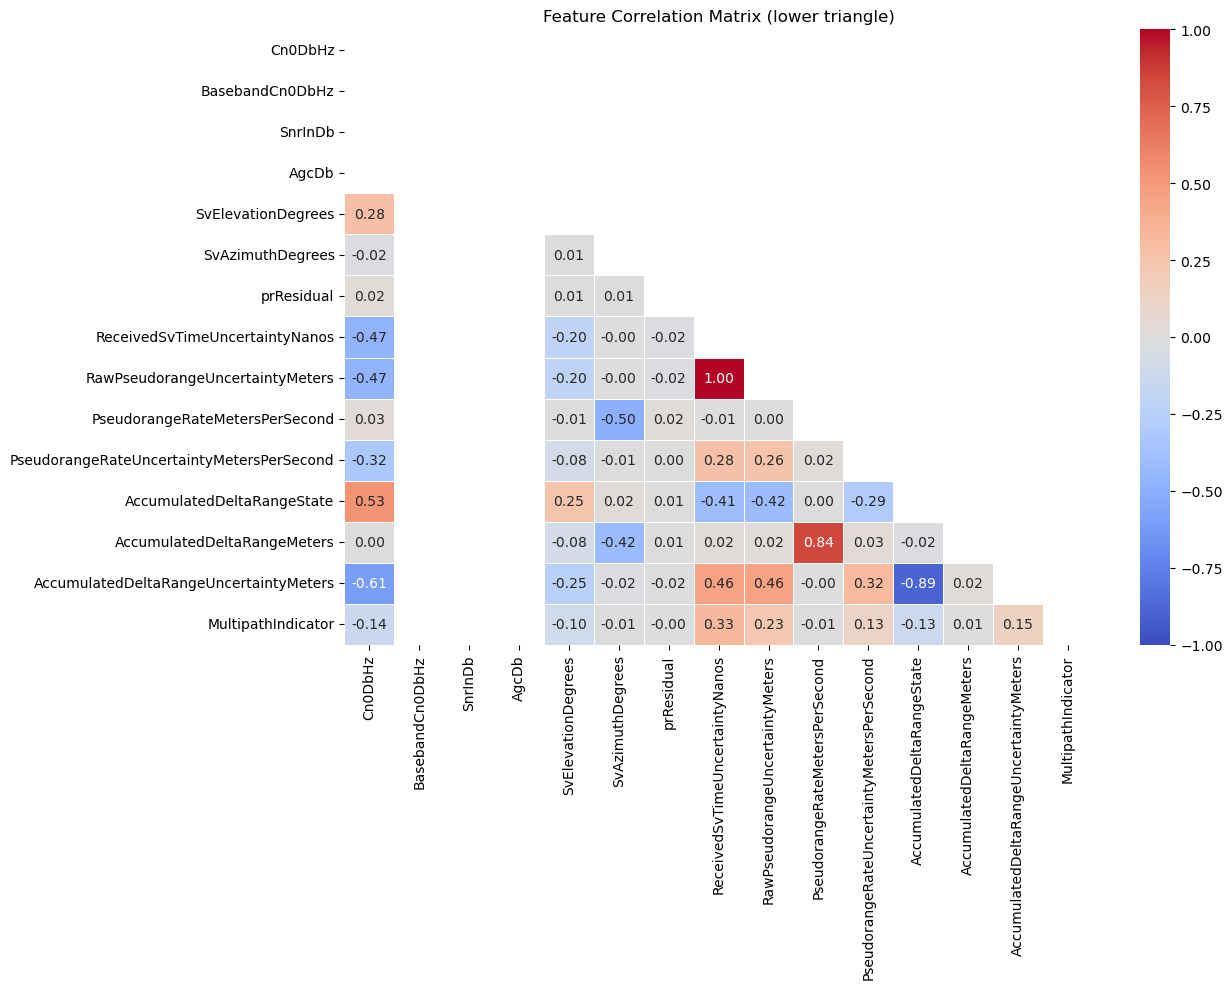


Correlation with MultipathIndicator (sorted):
ReceivedSvTimeUncertaintyNanos               0.326087
RawPseudorangeUncertaintyMeters              0.233263
AccumulatedDeltaRangeUncertaintyMeters       0.148334
Cn0DbHz                                     -0.140094
PseudorangeRateUncertaintyMetersPerSecond    0.129282
AccumulatedDeltaRangeState                  -0.128555
SvElevationDegrees                          -0.097259
SvAzimuthDegrees                            -0.014679
PseudorangeRateMetersPerSecond              -0.012860
AccumulatedDeltaRangeMeters                  0.009460
prResidual                                  -0.000264
BasebandCn0DbHz                                   NaN
SnrInDb                                           NaN
AgcDb                                             NaN
Name: MultipathIndicator, dtype: float64


In [ ]:
NUMERIC_FEATS = [
    'Cn0DbHz', 'BasebandCn0DbHz', 'SnrInDb', 'AgcDb',
    'SvElevationDegrees', 'SvAzimuthDegrees', 'prResidual',
    'ReceivedSvTimeUncertaintyNanos', 'RawPseudorangeUncertaintyMeters',
    'PseudorangeRateMetersPerSecond', 'PseudorangeRateUncertaintyMetersPerSecond',
    'AccumulatedDeltaRangeState', 'AccumulatedDeltaRangeMeters',
    'AccumulatedDeltaRangeUncertaintyMeters', 'MultipathIndicator',
]
available_num = [f for f in NUMERIC_FEATS if f in df.columns]
corr = df[available_num].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (lower triangle)')
plt.tight_layout()
plt.show()

print('\nCorrelation with MultipathIndicator (sorted):')
print(corr['MultipathIndicator'].drop('MultipathIndicator').sort_values(key=abs, ascending=False))

## 8. Feature Engineering

Adds a C/N0 signal-strength bucket, an elevation bucket, a `|prResidual|` magnitude feature, one-hot constellation encoding, and drops identifier / non-predictive columns.

In [ ]:
df_ml = df.copy()

df_ml['Cn0_Category'] = pd.cut(df_ml['Cn0DbHz'], bins=[0, 20, 30, 40, np.inf],
                               labels=['VeryWeak', 'Weak', 'Medium', 'Strong'], right=False)

if 'SvElevationDegrees' in df_ml.columns:
    df_ml['Elev_Category'] = pd.cut(df_ml['SvElevationDegrees'], bins=[-1, 15, 30, 60, 91],
                                    labels=['VeryLow', 'Low', 'Mid', 'High'])

if 'prResidual' in df_ml.columns:
    df_ml['AbsPrResidual'] = df_ml['prResidual'].abs()

df_ml = pd.get_dummies(df_ml, columns=['ConstellationName'], prefix='Const')

DROP_COLS = ['session', 'device', 'GpsTimeNanos', 'State', 'Svid',
             'ConstellationType', 'CarrierFrequencyHz']
df_ml.drop(columns=[c for c in DROP_COLS if c in df_ml.columns], inplace=True)

print('Features after engineering:')
print(list(df_ml.columns))
df_ml.head()

Features after engineering:
['ReceivedSvTimeUncertaintyNanos', 'Cn0DbHz', 'BasebandCn0DbHz', 'SnrInDb', 'AgcDb', 'PseudorangeRateMetersPerSecond', 'PseudorangeRateUncertaintyMetersPerSecond', 'AccumulatedDeltaRangeState', 'AccumulatedDeltaRangeMeters', 'AccumulatedDeltaRangeUncertaintyMeters', 'MultipathIndicator', 'SvElevationDegrees', 'SvAzimuthDegrees', 'RawPseudorangeMeters', 'RawPseudorangeUncertaintyMeters', 'prResidual', 'Cn0_Category', 'Elev_Category', 'AbsPrResidual', 'Const_BeiDou', 'Const_GPS', 'Const_Galileo', 'Const_QZSS']


,ReceivedSvTimeUncertaintyNanos,Cn0DbHz,BasebandCn0DbHz,SnrInDb,AgcDb,PseudorangeRateMetersPerSecond,PseudorangeRateUncertaintyMetersPerSecond,AccumulatedDeltaRangeState,AccumulatedDeltaRangeMeters,AccumulatedDeltaRangeUncertaintyMeters,MultipathIndicator,SvElevationDegrees,SvAzimuthDegrees,RawPseudorangeMeters,RawPseudorangeUncertaintyMeters,prResidual,Cn0_Category,Elev_Category,AbsPrResidual,Const_BeiDou,Const_GPS,Const_Galileo,Const_QZSS
0,14,41.710907,NaN,NaN,NaN,-164.962361,0.150000,25,-11668.937690,0.001196,0,54.479871,128.729618,2.090664e+07,4.197094,-17.517512,Strong,Mid,17.517512,False,True,False,False
1,50,26.527052,NaN,NaN,NaN,-534.366362,0.940767,29,-37277.453867,0.006478,0,28.062975,175.168830,2.299924e+07,14.989623,20.691331,Weak,Low,20.691331,False,True,False,False
2,27,34.177910,NaN,NaN,NaN,-402.783540,0.596536,25,-27997.748699,0.002685,0,23.090938,296.403147,2.329942e+07,8.094396,20.895644,Medium,Low,20.895644,False,True,False,False
3,14,42.474239,NaN,NaN,NaN,616.955107,0.150000,25,43134.044729,0.001096,0,36.711941,46.197646,2.242312e+07,4.197094,-19.880819,Strong,Mid,19.880819,False,True,False,False
4,16,40.274414,NaN,NaN,NaN,350.406984,0.150000,25,24380.856235,0.001411,0,67.378019,30.702359,2.035373e+07,4.796679,-5.631828,Strong,High,5.631828,False,True,False,False


## 9. Data Quality Check

In [ ]:
df_ml.replace([np.inf, -np.inf], np.nan, inplace=True)

nan_counts = df_ml.isnull().sum()
print('NaN counts per column:')
print(nan_counts[nan_counts > 0] if (nan_counts > 0).any() else '  None')

all_nan_cols = nan_counts[nan_counts == len(df_ml)].index.tolist()
if all_nan_cols:
    df_ml.drop(columns=all_nan_cols, inplace=True)
    print(f'\nDropped all-NaN columns: {all_nan_cols}')

# AgcDb is only partially populated on some devices -> median fill (guarded)
if 'AgcDb' in df_ml.columns and df_ml['AgcDb'].isna().any():
    df_ml['AgcDb'] = df_ml['AgcDb'].fillna(df_ml['AgcDb'].median())
    print('Filled AgcDb NaN with median')

CORE_COLS = ['Cn0DbHz', 'SvElevationDegrees', 'ReceivedSvTimeUncertaintyNanos',
             'PseudorangeRateMetersPerSecond', 'MultipathIndicator']
core_present = [c for c in CORE_COLS if c in df_ml.columns]
before = len(df_ml)
df_ml.dropna(subset=core_present, inplace=True)
print(f'\nRows dropped (missing core): {before - len(df_ml):,}  |  Remaining: {len(df_ml):,}')

NaN counts per column:
BasebandCn0DbHz                    761597
SnrInDb                            761597
AgcDb                              761597
SvElevationDegrees                  39765
SvAzimuthDegrees                    39765
RawPseudorangeMeters                39765
RawPseudorangeUncertaintyMeters     39765
prResidual                          39765
Elev_Category                       39765
AbsPrResidual                       39765
dtype: int64

Dropped all-NaN columns: ['BasebandCn0DbHz', 'SnrInDb', 'AgcDb']

Rows dropped (missing core): 39,765  |  Remaining: 721,832


## 10. Encode Category Features

⚠️ **No scaling here.** `StandardScaler` and SMOTE are fitted on **training data only** inside the classifier notebook (after the split) to avoid leaking test-set statistics.

In [ ]:
cat_cols = [c for c in ['Cn0_Category', 'Elev_Category'] if c in df_ml.columns]
if cat_cols:
    df_ml = pd.get_dummies(df_ml, columns=cat_cols, prefix=cat_cols)
    print(f'One-hot encoded: {cat_cols}')
else:
    print('Category columns already encoded — skipping')

print(f'Shape: {df_ml.shape}')
print(f'Columns: {list(df_ml.columns)}')

One-hot encoded: ['Cn0_Category', 'Elev_Category']
Shape: (721832, 26)
Columns: ['ReceivedSvTimeUncertaintyNanos', 'Cn0DbHz', 'PseudorangeRateMetersPerSecond', 'PseudorangeRateUncertaintyMetersPerSecond', 'AccumulatedDeltaRangeState', 'AccumulatedDeltaRangeMeters', 'AccumulatedDeltaRangeUncertaintyMeters', 'MultipathIndicator', 'SvElevationDegrees', 'SvAzimuthDegrees', 'RawPseudorangeMeters', 'RawPseudorangeUncertaintyMeters', 'prResidual', 'AbsPrResidual', 'Const_BeiDou', 'Const_GPS', 'Const_Galileo', 'Const_QZSS', 'Cn0_Category_VeryWeak', 'Cn0_Category_Weak', 'Cn0_Category_Medium', 'Cn0_Category_Strong', 'Elev_Category_VeryLow', 'Elev_Category_Low', 'Elev_Category_Mid', 'Elev_Category_High']


## 11. Class Imbalance — Overview

Raw imbalance before any resampling. SMOTE is applied inside the classifier notebook on training data only.

In [ ]:
X = df_ml.drop(columns=['MultipathIndicator'])
y = df_ml['MultipathIndicator'].astype(int)
counts = y.value_counts()
total = len(y)
print('Class distribution (raw, pre-split):')
for cls, cnt in counts.items():
    print(f'  {cls}: {cnt:,}  ({100*cnt/total:.1f}%)')
print(f'\nImbalance ratio: {counts[0]/counts[1]:.1f}:1  ->  SMOTE will balance this in the classifier.')

Class distribution (raw, pre-split):
  0: 676,446  (93.7%)
  1: 45,386  (6.3%)

Imbalance ratio: 14.9:1  ->  SMOTE will balance this in the classifier.


## 12. PCA — Variance Explained (raw, unscaled)

Orientation only — uses the unscaled numeric matrix so PCA reflects true variance magnitudes.

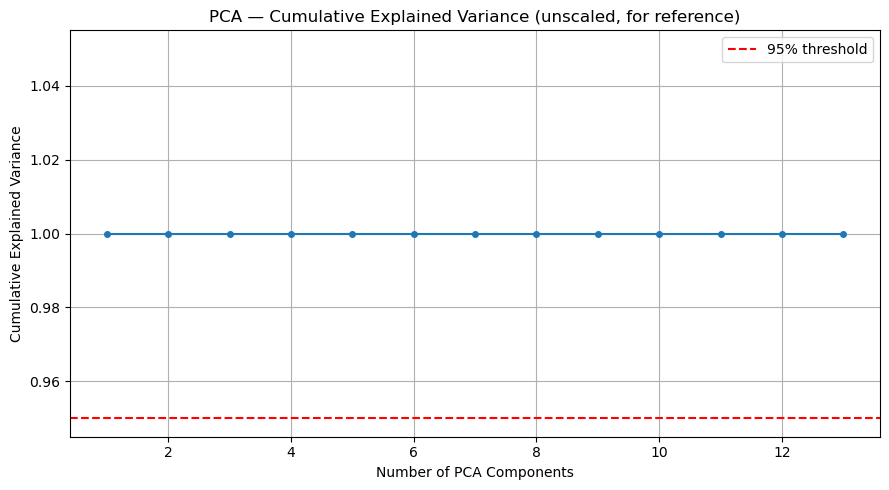

Components needed to explain 95% of variance: 1


In [ ]:
bool_cols = X.select_dtypes(include='bool').columns.tolist()
num_cols  = [c for c in X.select_dtypes(include=np.number).columns if c not in bool_cols]

pca = PCA()
pca.fit(X[num_cols].fillna(0))
cumvar = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumvar) + 1), cumvar, marker='o', markersize=4)
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance (unscaled, for reference)')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

n95 = int(np.where(cumvar >= 0.95)[0][0]) + 1
print(f'Components needed to explain 95% of variance: {n95}')

## 13. Export Training Features

In [ ]:
# Raw (unscaled, pre-SMOTE) features. Scaling + SMOTE happen in
# 03_2023_classification.ipynb AFTER the train/test split to prevent leakage.
df_ml.to_csv(OUTPUT_CSV, index=False)
print(f'Saved {len(df_ml):,} rows  ->  {OUTPUT_CSV}')
print(f'Shape: {df_ml.shape}')
df_ml.head()

Saved 721,832 rows  ->  C:\Users\Dell\Documents\Warwick\Diss\Code\Dissertation_Trial\GNSS_Multipath_Project\data/03_processed\sdc2023_training_features.csv
Shape: (721832, 26)


,ReceivedSvTimeUncertaintyNanos,Cn0DbHz,PseudorangeRateMetersPerSecond,PseudorangeRateUncertaintyMetersPerSecond,AccumulatedDeltaRangeState,AccumulatedDeltaRangeMeters,AccumulatedDeltaRangeUncertaintyMeters,MultipathIndicator,SvElevationDegrees,SvAzimuthDegrees,RawPseudorangeMeters,RawPseudorangeUncertaintyMeters,prResidual,AbsPrResidual,Const_BeiDou,Const_GPS,Const_Galileo,Const_QZSS,Cn0_Category_VeryWeak,Cn0_Category_Weak,Cn0_Category_Medium,Cn0_Category_Strong,Elev_Category_VeryLow,Elev_Category_Low,Elev_Category_Mid,Elev_Category_High
0,14,41.710907,-164.962361,0.150000,25,-11668.937690,0.001196,0,54.479871,128.729618,2.090664e+07,4.197094,-17.517512,17.517512,False,True,False,False,False,False,False,True,False,False,True,False
1,50,26.527052,-534.366362,0.940767,29,-37277.453867,0.006478,0,28.062975,175.168830,2.299924e+07,14.989623,20.691331,20.691331,False,True,False,False,False,True,False,False,False,True,False,False
2,27,34.177910,-402.783540,0.596536,25,-27997.748699,0.002685,0,23.090938,296.403147,2.329942e+07,8.094396,20.895644,20.895644,False,True,False,False,False,False,True,False,False,True,False,False
3,14,42.474239,616.955107,0.150000,25,43134.044729,0.001096,0,36.711941,46.197646,2.242312e+07,4.197094,-19.880819,19.880819,False,True,False,False,False,False,False,True,False,False,True,False
4,16,40.274414,350.406984,0.150000,25,24380.856235,0.001411,0,67.378019,30.702359,2.035373e+07,4.796679,-5.631828,5.631828,False,True,False,False,False,False,False,True,False,False,False,True
